# Modeling — Logistic regression + evaluation

Pipeline:
1. Load and inspect the Ligue 1 dataset
2. Temporal train/test split (last season held out)
3. Baseline: Understat win probabilities
4. Multinomial logistic regression on team-level features
5. Metrics: log-loss, Brier, accuracy
6. Comparison across 3 feature regimes (team / +FBref / +player)

Inputs come from the CSVs in `../data/`, produced by `data_construction/04_feature_engineering.ipynb`.

## Step 1 — Load and inspect

In [3]:
# Imports — libraries used throughout the notebook.
import pandas as pd            # for loading and manipulating the CSV as a table (DataFrame)
import numpy as np             # for numerical operations
import matplotlib.pyplot as plt # for plots

# Display options: show all columns when printing a DataFrame.
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 200)

# Reproducibility: fix the random seed so results are stable across runs.
RANDOM_STATE = 42

In [5]:
# 1.1 — Load the main CSV (team-level features, Ligue 1).
# Produced by Sienna/Alfred in `data_construction/04_feature_engineering.ipynb`.
# 2092 matches (6 seasons: 2018/19 to 2023/24), 40 columns.

df = pd.read_csv('../data/ligue1_features.csv', parse_dates=['date'])

print(f'Number of matches (rows): {len(df)}')
print(f'Number of columns       : {df.shape[1]}')
print(f'Date range              : {df["date"].min().date()} to {df["date"].max().date()}')

Number of matches (rows): 2092
Number of columns       : 40
Date range              : 2018-08-17 to 2024-05-19


In [7]:
# 1.2 — Preview: the first 5 rows of the table.
df.head()

,match_id,date,season,match_week,home_team,away_team,home_roll_xg_for,home_roll_xg_against,home_roll_xg_diff,away_roll_xg_for,away_roll_xg_against,away_roll_xg_diff,net_xg_diff,home_roll_goals_for,home_roll_goals_against,home_roll_goal_diff,away_roll_goals_for,away_roll_goals_against,away_roll_goal_diff,net_goal_diff,home_roll_won,away_roll_won,net_win_rate,home_roll_points,away_roll_points,net_points,home_squad_value,away_squad_value,squad_value_ratio,log_squad_value_ratio,squad_value_diff,home_avg_player_value,away_avg_player_value,home_squad_age,away_squad_age,home_win_prob,draw_prob,away_win_prob,result,result_code
0,10653,2018-08-17,2018,2,Reims,Lyon,0.267420,1.032630,-0.765210,1.30809,0.286084,1.022006,-1.787216,1.0,0.0,1.0,2.0,0.0,2.0,-1.0,1.0,1.0,0.0,3.0,3.0,0.0,55000000,320000000,0.171875,-1.760988,-265000000,2391304.0,12800000.0,25.5,25.6,0.2462,0.3489,0.4049,H,0
1,10654,2018-08-18,2018,3,Guingamp,Paris Saint Germain,1.372170,0.934842,0.437328,3.34692,0.189346,3.157574,-2.720246,1.0,2.0,-1.0,3.0,0.0,3.0,-4.0,0.0,1.0,-1.0,0.0,3.0,-3.0,35000000,780000000,0.044872,-3.103946,-745000000,1590909.0,30000000.0,26.5,25.8,0.1246,0.1829,0.6925,A,2
2,10655,2018-08-18,2018,3,Monaco,Lille,2.841300,1.220550,1.620750,1.88164,0.447458,1.434182,0.186568,3.0,1.0,2.0,3.0,1.0,2.0,0.0,1.0,1.0,0.0,3.0,3.0,0.0,380000000,180000000,2.111111,0.747214,200000000,15200000.0,7500000.0,24.2,25.1,0.6904,0.2162,0.0934,D,1
3,10656,2018-08-18,2018,3,Rennes,Angers,0.447458,1.881640,-1.434182,2.62438,1.213760,1.410620,-2.844802,1.0,3.0,-2.0,3.0,4.0,-1.0,-1.0,0.0,0.0,0.0,0.0,0.0,0.0,140000000,50000000,2.800000,1.029619,90000000,5833333.0,2272727.0,24.6,26.5,0.2485,0.5415,0.2100,H,0
4,10657,2018-08-18,2018,3,Amiens,Montpellier,0.286084,1.308090,-1.022006,1.34076,1.948170,-0.607410,-0.414596,0.0,2.0,-2.0,1.0,2.0,-1.0,-1.0,0.0,0.0,0.0,0.0,0.0,0.0,42000000,85000000,0.494118,-0.704982,-43000000,1909091.0,3695652.0,26.0,26.0,0.6584,0.2750,0.0666,A,2


In [9]:
# 1.3 — All columns grouped by family, so we know what features we have.
# Detailed documentation in `data/schema.md`.

id_cols       = ['match_id', 'date', 'season', 'match_week', 'home_team', 'away_team']
rolling_xg    = [c for c in df.columns if 'roll_xg' in c or 'net_xg' in c]
rolling_goals = [c for c in df.columns if 'roll_goal' in c or 'net_goal' in c]
rolling_form  = [c for c in df.columns if 'roll_won' in c or 'win_rate' in c or 'points' in c]
squad_value   = [c for c in df.columns if 'squad' in c or 'player_value' in c]
understat     = ['home_win_prob', 'draw_prob', 'away_win_prob']
target        = ['result', 'result_code']

print('Identifiers & context :', id_cols)
print()
print('Rolling xG (last 5 matches) :', rolling_xg)
print()
print('Rolling goals (last 5 matches) :', rolling_goals)
print()
print('Rolling form (win rate, points) :', rolling_form)
print()
print('Transfermarkt market values :', squad_value)
print()
print('Understat forecasts (USED AS BASELINE — see step 3) :', understat)
print()
print('Target :', target)

Identifiers & context : ['match_id', 'date', 'season', 'match_week', 'home_team', 'away_team']

Rolling xG (last 5 matches) : ['home_roll_xg_for', 'home_roll_xg_against', 'home_roll_xg_diff', 'away_roll_xg_for', 'away_roll_xg_against', 'away_roll_xg_diff', 'net_xg_diff']

Rolling goals (last 5 matches) : ['home_roll_goals_for', 'home_roll_goals_against', 'home_roll_goal_diff', 'away_roll_goals_for', 'away_roll_goals_against', 'away_roll_goal_diff', 'net_goal_diff']

Rolling form (win rate, points) : ['home_roll_won', 'away_roll_won', 'net_win_rate', 'home_roll_points', 'away_roll_points', 'net_points']

Transfermarkt market values : ['home_squad_value', 'away_squad_value', 'squad_value_ratio', 'log_squad_value_ratio', 'squad_value_diff', 'home_avg_player_value', 'away_avg_player_value', 'home_squad_age', 'away_squad_age']

Understat forecasts (USED AS BASELINE — see step 3) : ['home_win_prob', 'draw_prob', 'away_win_prob']

Target : ['result', 'result_code']


In [11]:
# 1.4 — Class distribution: H / D / A.
# Important to understand imbalance (draws are rare -> ML discussion point).

counts = df['result'].value_counts()
shares = df['result'].value_counts(normalize=True)

print('Result distribution:')
for cls in ['H', 'D', 'A']:
    label = 'Home win' if cls == 'H' else 'Draw' if cls == 'D' else 'Away win'
    print(f'  {cls} ({label:9}) : {counts[cls]:4d} matches ({shares[cls]*100:5.1f} %)')

print()
print('Numeric encoding (result_code):')
print(df.groupby('result')['result_code'].first().to_dict())

Result distribution:
  H (Home win ) :  879 matches ( 42.0 %)
  D (Draw     ) :  549 matches ( 26.2 %)
  A (Away win ) :  664 matches ( 31.7 %)

Numeric encoding (result_code):
{'A': 2, 'D': 1, 'H': 0}


In [13]:
# 1.5 — Matches per season.
# Helps decide the temporal split — ideally we hold out season 2023/24 entirely.

by_season = df.groupby('season').agg(
    n_matches=('match_id', 'count'),
    first_date=('date', 'min'),
    last_date=('date', 'max'),
)
print(by_season)

        n_matches first_date  last_date
season                                 
2018          370 2018-08-17 2019-05-24
2019          278 2019-08-09 2020-03-08
2020          379 2020-08-21 2021-05-23
2021          379 2021-08-06 2022-05-21
2022          380 2022-08-05 2023-06-03
2023          306 2023-08-12 2024-05-19


In [15]:
# 1.6 — Missing values (NaN).
# We need to know where they are and how many before training any model.

missing = df.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)

if missing.empty:
    print('No missing values.')
else:
    print(f'{len(missing)} columns have missing values:')
    for col, n in missing.items():
        print(f'  {col:30s} {n:4d} NaN ({n/len(df)*100:.2f} %)')


12 columns have missing values:
  away_roll_xg_for                  6 NaN (0.29 %)
  away_roll_xg_against              6 NaN (0.29 %)
  away_roll_xg_diff                 6 NaN (0.29 %)
  net_xg_diff                       6 NaN (0.29 %)
  away_roll_goals_for               6 NaN (0.29 %)
  away_roll_goals_against           6 NaN (0.29 %)
  away_roll_goal_diff               6 NaN (0.29 %)
  net_goal_diff                     6 NaN (0.29 %)
  away_roll_won                     6 NaN (0.29 %)
  net_win_rate                      6 NaN (0.29 %)
  away_roll_points                  6 NaN (0.29 %)
  net_points                        6 NaN (0.29 %)


## Step 2 — Temporal split

Train on seasons 2018–2022, hold out season 2023/24 as the test set. A season-based cut is more interpretable than "last 20 % by date": a whole season is a natural unit (all teams play each other twice).

No standard k-fold here. K-fold would shuffle past and future matches, training on May 2024 to predict August 2018 — temporal leakage. `TimeSeriesSplit` is reserved for hyperparameter tuning later; the final evaluation uses a single fixed split.

In [18]:
# 2.1 — Drop the 6 rows with NaN (first matches of promoted clubs, 0.3 % of data).
# Keep the original df untouched for reference.

df_clean = df.dropna().reset_index(drop=True)
print(f'Before drop: {len(df):4d} matches')
print(f'After drop : {len(df_clean):4d} matches')
print(f'Dropped    : {len(df) - len(df_clean):4d} matches')

Before drop: 2092 matches
After drop : 2086 matches
Dropped    :    6 matches


In [20]:
# 2.2 — Sort by date. Critical — every step downstream assumes chronological order.

df_clean = df_clean.sort_values('date').reset_index(drop=True)
print(f'Earliest match: {df_clean["date"].min().date()}')
print(f'Latest match  : {df_clean["date"].max().date()}')

Earliest match: 2018-08-17
Latest match  : 2024-05-19


In [22]:
# 2.3 — Define the train / test split using the `season` column.
#   - Train: seasons 2018, 2019, 2020, 2021, 2022 (5 seasons)
#   - Test : season 2023 (the 2023/24 season)

TEST_SEASON = 2023

train_mask = df_clean['season'] < TEST_SEASON
test_mask  = df_clean['season'] == TEST_SEASON

df_train = df_clean[train_mask].reset_index(drop=True)
df_test  = df_clean[test_mask].reset_index(drop=True)

print(f'Train set: {len(df_train)} matches (seasons {df_train["season"].min()} to {df_train["season"].max()})')
print(f'Test set : {len(df_test)} matches (season {df_test["season"].iloc[0]} only)')
print(f'Test share: {len(df_test)/len(df_clean)*100:.1f} %')

Train set: 1781 matches (seasons 2018 to 2022)
Test set : 305 matches (season 2023 only)
Test share: 14.6 %


In [24]:
# 2.4 — Sanity check: verify no temporal leakage.
# Every train date must be strictly BEFORE every test date.

train_max_date = df_train['date'].max()
test_min_date  = df_test['date'].min()

print(f'Last train date : {train_max_date.date()}')
print(f'First test date : {test_min_date.date()}')

assert train_max_date < test_min_date, (
    f'TEMPORAL LEAKAGE: last train date {train_max_date} >= first test date {test_min_date}'
)
print('OK — no temporal leakage: every train match happens before every test match.')

Last train date : 2023-06-03
First test date : 2023-08-12
OK — no temporal leakage: every train match happens before every test match.


In [26]:
# 2.5 — Class distribution: train vs test.
# If they're very different, the test season is unusual and metrics will be misleading.

train_dist = df_train['result'].value_counts(normalize=True).sort_index()
test_dist  = df_test['result'].value_counts(normalize=True).sort_index()

comparison = pd.DataFrame({
    'train_share': train_dist,
    'test_share' : test_dist,
    'difference' : (test_dist - train_dist).round(3),
})
print('Class distribution: train vs test')
print(comparison)

Class distribution: train vs test
        train_share  test_share  difference
result                                     
A          0.313307    0.344262       0.031
D          0.262212    0.262295       0.000
H          0.424481    0.393443      -0.031


In [28]:
# 2.6 — Define the feature set for the first model (logistic regression).
# IMPORTANT: we EXCLUDE the Understat win_probs because they will serve as our baseline
# (see step 3). If we kept them in the features, the model would have access to the
# baseline's predictions during training — circular reasoning that would make any
# comparison meaningless.

FEATURES_TEAM = (
    rolling_xg
    + rolling_goals
    + rolling_form
    + squad_value
    # understat probs are NOT in features — they are the baseline
)

print(f'Number of features in regime A (team-level, no Understat): {len(FEATURES_TEAM)}')
print()
print('Features:')
for f in FEATURES_TEAM:
    print(f'  - {f}')

Number of features in regime A (team-level, no Understat): 29

Features:
  - home_roll_xg_for
  - home_roll_xg_against
  - home_roll_xg_diff
  - away_roll_xg_for
  - away_roll_xg_against
  - away_roll_xg_diff
  - net_xg_diff
  - home_roll_goals_for
  - home_roll_goals_against
  - home_roll_goal_diff
  - away_roll_goals_for
  - away_roll_goals_against
  - away_roll_goal_diff
  - net_goal_diff
  - home_roll_won
  - away_roll_won
  - net_win_rate
  - home_roll_points
  - away_roll_points
  - net_points
  - home_squad_value
  - away_squad_value
  - squad_value_ratio
  - log_squad_value_ratio
  - squad_value_diff
  - home_avg_player_value
  - away_avg_player_value
  - home_squad_age
  - away_squad_age


In [30]:
# 2.7 — Build the X / y arrays for train and test.
#   X = the features (input to the model)
#   y = the target (what we predict). We use result_code (0=H, 1=D, 2=A).

X_train = df_train[FEATURES_TEAM].values
y_train = df_train['result_code'].values

X_test  = df_test[FEATURES_TEAM].values
y_test  = df_test['result_code'].values

print(f'X_train shape: {X_train.shape}  (rows, features)')
print(f'y_train shape: {y_train.shape}')
print(f'X_test  shape: {X_test.shape}')
print(f'y_test  shape: {y_test.shape}')

X_train shape: (1781, 29)  (rows, features)
y_train shape: (1781,)
X_test  shape: (305, 29)
y_test  shape: (305,)


## Step 3 — Baseline: Understat win probabilities

The baseline is the Understat win-probability forecast (`home_win_prob`, `draw_prob`, `away_win_prob`) — pre-match estimates derived from their xG model. Available before each match, so no leakage.

The model's log-loss is meaningless without a reference. Understat is a strong, well-calibrated reference because their xG model is itself a serious forecasting system.

These probabilities are NOT used as features in the model (excluded in step 2.6). Using them in both places would be circular reasoning.

In [33]:
# 3.1 — Extract the Understat probabilities for the TEST set only.
# (The baseline only needs to produce predictions on the test set — that's where we evaluate.)
#
# Order matters: we put the columns in the order [home, draw, away] to match result_code
# (H=0, D=1, A=2). So baseline_proba_test[:, 0] = P(H), [:, 1] = P(D), [:, 2] = P(A).

baseline_proba_test = df_test[['home_win_prob', 'draw_prob', 'away_win_prob']].values

print(f'baseline_proba_test shape: {baseline_proba_test.shape}  (rows, 3 classes)')
print()
print('First 5 rows (each row sums to ~1):')
for i in range(5):
    row = baseline_proba_test[i]
    print(f'  Match {i+1}: P(H)={row[0]:.3f}  P(D)={row[1]:.3f}  P(A)={row[2]:.3f}'
          f'   (sum={row.sum():.3f})')

baseline_proba_test shape: (305, 3)  (rows, 3 classes)

First 5 rows (each row sums to ~1):
  Match 1: P(H)=0.725  P(D)=0.243  P(A)=0.032   (sum=1.000)
  Match 2: P(H)=0.853  P(D)=0.105  P(A)=0.042   (sum=1.000)
  Match 3: P(H)=0.502  P(D)=0.291  P(A)=0.208   (sum=1.000)
  Match 4: P(H)=0.239  P(D)=0.290  P(A)=0.472   (sum=1.000)
  Match 5: P(H)=0.989  P(D)=0.010  P(A)=0.001   (sum=1.000)


In [35]:
# 3.2 — Sanity check: probabilities should sum to (approximately) 1 for each match.
# Understat normalises them, but rounding can produce ~0.999 or ~1.001.

row_sums = baseline_proba_test.sum(axis=1)
print('Row sum stats:')
print(f'  min  = {row_sums.min():.4f}')
print(f'  max  = {row_sums.max():.4f}')
print(f'  mean = {row_sums.mean():.4f}')

# If any row deviates more than 1 % from 1.0, normalise to be safe.
if np.abs(row_sums - 1).max() > 0.01:
    print('Renormalising rows to sum to 1.')
    baseline_proba_test = baseline_proba_test / row_sums[:, None]
else:
    print('All rows sum to ~1 within tolerance, no normalisation needed.')

Row sum stats:
  min  = 1.0000
  max  = 1.0000
  mean = 1.0000
All rows sum to ~1 within tolerance, no normalisation needed.


In [37]:
# 3.3 — Inspect baseline predictions: which class would the baseline pick for each match?
# argmax = the class with the highest probability. This is just for inspection —
# log-loss / Brier will use the full probability vector, not the argmax.

baseline_pred_class = baseline_proba_test.argmax(axis=1)  # 0=H, 1=D, 2=A
label_map = {0: 'H', 1: 'D', 2: 'A'}

preview = df_test[['date', 'home_team', 'away_team', 'result']].copy()
preview['baseline_pred'] = [label_map[c] for c in baseline_pred_class]
preview['P(H)'] = baseline_proba_test[:, 0].round(3)
preview['P(D)'] = baseline_proba_test[:, 1].round(3)
preview['P(A)'] = baseline_proba_test[:, 2].round(3)
preview.head(10)

,date,home_team,away_team,result,baseline_pred,P(H),P(D),P(A)
0,2023-08-12,Paris Saint Germain,Lorient,D,H,0.725,0.243,0.032
1,2023-08-12,Brest,Lens,H,H,0.852,0.105,0.042
2,2023-08-12,Marseille,Reims,H,H,0.502,0.291,0.208
3,2023-08-12,Nice,Lille,D,A,0.239,0.290,0.472
4,2023-08-13,Rennes,Metz,H,H,0.989,0.010,0.001
5,2023-08-13,Strasbourg,Lyon,H,A,0.164,0.239,0.597
6,2023-08-13,Nantes,Toulouse,A,A,0.125,0.239,0.636
7,2023-08-13,Clermont Foot,Monaco,A,A,0.100,0.163,0.737
8,2023-08-18,Metz,Marseille,D,A,0.070,0.233,0.696
9,2023-08-19,Toulouse,Paris Saint Germain,D,A,0.151,0.256,0.592


In [39]:
# 3.4 — How often does the baseline "argmax-predict" each class? Compared to the actual rate?
# Useful to spot whether the baseline is biased toward any class.

import collections
pred_counts   = collections.Counter(baseline_pred_class)
actual_counts = collections.Counter(y_test)

summary = pd.DataFrame({
    'actual_count'   : [actual_counts[c] for c in range(3)],
    'actual_share'   : [actual_counts[c] / len(y_test) for c in range(3)],
    'baseline_count' : [pred_counts[c] for c in range(3)],
    'baseline_share' : [pred_counts[c] / len(y_test) for c in range(3)],
}, index=['H (0)', 'D (1)', 'A (2)'])

print('Baseline (argmax) vs actual results, on the test set:')
print(summary.round(3))

Baseline (argmax) vs actual results, on the test set:
       actual_count  actual_share  baseline_count  baseline_share
H (0)           120         0.393             186           0.610
D (1)            80         0.262               9           0.030
A (2)           105         0.344             110           0.361


## Step 4 — Multinomial logistic regression

Train on the 29 team-level features (regime A) and generate predicted probabilities on the test set.

Two implementation notes:

1. **Feature scaling.** Features live on very different scales: `home_squad_value` is in the tens of millions of euros, `home_roll_xg_for` is between 0 and 3. `StandardScaler` brings everything to mean 0, std 1. Without scaling, the gradient-based solver is dominated by the large-scale features.

2. **Fit only on the training set.** `StandardScaler.fit_transform()` on training data, `.transform()` on test data with the same parameters. Fitting on the test set would be a form of leakage.

In [42]:
# 4.1 — Why scaling matters: look at the range of each feature.
# If some features are 1000x larger than others, the model will be biased toward them.

feature_stats = pd.DataFrame({
    'min'  : df_train[FEATURES_TEAM].min(),
    'max'  : df_train[FEATURES_TEAM].max(),
    'mean' : df_train[FEATURES_TEAM].mean(),
    'std'  : df_train[FEATURES_TEAM].std(),
})
print('Train feature ranges (notice the scale gap between squad_value and rolling features):')
print(feature_stats.round(2))

Train feature ranges (notice the scale gap between squad_value and rolling features):
                                  min           max          mean           std
home_roll_xg_for         1.900000e-01  3.990000e+00  1.320000e+00  5.000000e-01
home_roll_xg_against     9.000000e-02  3.490000e+00  1.350000e+00  4.400000e-01
home_roll_xg_diff       -3.230000e+00  3.300000e+00 -3.000000e-02  7.700000e-01
away_roll_xg_for         9.000000e-02  4.020000e+00  1.350000e+00  5.200000e-01
away_roll_xg_against     1.900000e-01  3.200000e+00  1.320000e+00  4.300000e-01
away_roll_xg_diff       -2.410000e+00  3.340000e+00  4.000000e-02  7.800000e-01
net_xg_diff             -4.640000e+00  3.790000e+00 -6.000000e-02  1.090000e+00
home_roll_goals_for      0.000000e+00  5.200000e+00  1.340000e+00  6.500000e-01
home_roll_goals_against  0.000000e+00  4.000000e+00  1.360000e+00  6.100000e-01
home_roll_goal_diff     -4.000000e+00  4.600000e+00 -2.000000e-02  9.800000e-01
away_roll_goals_for      0.000000e

In [44]:
# 4.2 — Standardise the features: mean=0, std=1.
# Fit on X_train ONLY (otherwise we'd leak test-set info into the scaler).

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)  # fit + transform on train
X_test_scaled  = scaler.transform(X_test)       # transform-only on test (uses train's mean/std)

print('After scaling:')
print(f'  X_train_scaled mean: {X_train_scaled.mean():.4f}  (should be ~0)')
print(f'  X_train_scaled std : {X_train_scaled.std():.4f}   (should be ~1)')
print(f'  X_test_scaled  mean: {X_test_scaled.mean():.4f}   (close to 0 — not exactly 0 because')
print(f'                                                  the scaler was fit on train only)')
print(f'  X_test_scaled  std : {X_test_scaled.std():.4f}    (close to 1 — same reason)')

After scaling:
  X_train_scaled mean: 0.0000  (should be ~0)
  X_train_scaled std : 1.0000   (should be ~1)
  X_test_scaled  mean: 0.0484   (close to 0 — not exactly 0 because
                                                  the scaler was fit on train only)
  X_test_scaled  std : 0.9530    (close to 1 — same reason)


In [45]:
# 4.3 — Train a multinomial logistic regression.
# Multinomial softmax over 3 classes is the default in scikit-learn 1.5+ and is the right setup for H/D/A.
# - `solver='lbfgs'` works with multinomial.
# - `max_iter=1000` to ensure the optimiser converges (default 100 can be too few).
# - `C=1.0` is the inverse of regularisation strength. Default; tune later.
# - `random_state` for reproducibility.

from sklearn.linear_model import LogisticRegression

logreg = LogisticRegression(
    solver='lbfgs',
    C=1.0,
    max_iter=1000,
    random_state=RANDOM_STATE,
)
logreg.fit(X_train_scaled, y_train)

print('Logistic regression trained.')
print(f'  classes_ (sklearn-internal class order) : {logreg.classes_}')
print(f'  coef_ shape (classes x features)        : {logreg.coef_.shape}')
print(f'  intercept_ shape                        : {logreg.intercept_.shape}')

Logistic regression trained.
  classes_ (sklearn-internal class order) : [0 1 2]
  coef_ shape (classes x features)        : (3, 29)
  intercept_ shape                        : (3,)


In [46]:
# 4.4 — Predict probabilities on the TEST set.
# `predict_proba` returns a (n_test, 3) array of probabilities — same shape as baseline_proba_test.

logreg_proba_test = logreg.predict_proba(X_test_scaled)

print(f'logreg_proba_test shape: {logreg_proba_test.shape}  (rows, 3 classes)')
print()
print('First 5 predictions (each row sums to 1):')
for i in range(5):
    row = logreg_proba_test[i]
    print(f'  Match {i+1}: P(H)={row[0]:.3f}  P(D)={row[1]:.3f}  P(A)={row[2]:.3f}'
          f'   (sum={row.sum():.3f})')

logreg_proba_test shape: (305, 3)  (rows, 3 classes)

First 5 predictions (each row sums to 1):
  Match 1: P(H)=0.850  P(D)=0.074  P(A)=0.076   (sum=1.000)
  Match 2: P(H)=0.215  P(D)=0.358  P(A)=0.427   (sum=1.000)
  Match 3: P(H)=0.549  P(D)=0.232  P(A)=0.219   (sum=1.000)
  Match 4: P(H)=0.433  P(D)=0.250  P(A)=0.317   (sum=1.000)
  Match 5: P(H)=0.683  P(D)=0.230  P(A)=0.087   (sum=1.000)


In [47]:
# 4.5 — Side-by-side comparison: logistic regression vs baseline (Understat) vs truth.
# Just visual inspection — we'll compute the actual scores in step 5.

logreg_pred_class = logreg_proba_test.argmax(axis=1)

preview = df_test[['date', 'home_team', 'away_team', 'result']].copy()
preview['baseline_pred'] = [label_map[c] for c in baseline_pred_class]
preview['logreg_pred']   = [label_map[c] for c in logreg_pred_class]
preview['logreg_P(H)']   = logreg_proba_test[:, 0].round(3)
preview['logreg_P(D)']   = logreg_proba_test[:, 1].round(3)
preview['logreg_P(A)']   = logreg_proba_test[:, 2].round(3)
preview.head(10)

,date,home_team,away_team,result,baseline_pred,logreg_pred,logreg_P(H),logreg_P(D),logreg_P(A)
0,2023-08-12,Paris Saint Germain,Lorient,D,H,H,0.850,0.074,0.076
1,2023-08-12,Brest,Lens,H,H,A,0.215,0.358,0.427
2,2023-08-12,Marseille,Reims,H,H,H,0.549,0.232,0.219
3,2023-08-12,Nice,Lille,D,A,H,0.433,0.250,0.317
4,2023-08-13,Rennes,Metz,H,H,H,0.683,0.230,0.087
5,2023-08-13,Strasbourg,Lyon,H,A,A,0.334,0.256,0.410
6,2023-08-13,Nantes,Toulouse,A,A,H,0.352,0.338,0.310
7,2023-08-13,Clermont Foot,Monaco,A,A,A,0.226,0.171,0.603
8,2023-08-18,Metz,Marseille,D,A,A,0.159,0.147,0.694
9,2023-08-19,Toulouse,Paris Saint Germain,D,A,A,0.239,0.131,0.629


In [49]:
# 4.6 — Distribution of argmax predictions vs actual results (same kind of check as step 3.4).
# Useful to spot bias.

pred_counts_logreg = collections.Counter(logreg_pred_class)

summary = pd.DataFrame({
    'actual_share'   : [actual_counts[c] / len(y_test) for c in range(3)],
    'baseline_share' : [pred_counts[c] / len(y_test) for c in range(3)],
    'logreg_share'   : [pred_counts_logreg[c] / len(y_test) for c in range(3)],
}, index=['H (0)', 'D (1)', 'A (2)'])

print('Argmax prediction distribution: actual vs baseline vs logistic regression')
print(summary.round(3))

Argmax prediction distribution: actual vs baseline vs logistic regression
       actual_share  baseline_share  logreg_share
H (0)         0.393           0.610         0.626
D (1)         0.262           0.030         0.036
A (2)         0.344           0.361         0.338


## Step 5 — Evaluation

Three metrics:

1. **Log-loss (cross-entropy).** $-\log(p_{\text{true class}})$ averaged over the test set. Penalises confident wrong predictions heavily. Lower is better — 0 is perfect, 1.099 is uniform (1/3 per class).

2. **Brier score (multi-class).** Mean of sum of squared errors across classes. Less aggressive on outliers than log-loss but consistent with it. Range 0 (perfect) to 2.

3. **Accuracy.** Argmax-based. Reported for context but not the primary metric — with class imbalance (H = 42 %), it's easy to game by always predicting the majority class.

In [55]:
# 5.1 — Log-loss.
# sklearn's log_loss handles multi-class natively: just pass proba (N, 3) and labels (N,).
# sklearn clips probabilities to [eps, 1-eps] internally to avoid log(0).

from sklearn.metrics import log_loss

logloss_baseline = log_loss(y_test, baseline_proba_test, labels=[0, 1, 2])
logloss_logreg   = log_loss(y_test, logreg_proba_test,   labels=[0, 1, 2])

# Reference: uniform predictor (1/3 for each class)
logloss_uniform = -np.log(1/3)  # ~1.099

print('Log-loss (lower is better):')
print(f'  Uniform (reference)    : {logloss_uniform:.4f}   (a predictor that says 1/3 for everything)')
print(f'  Baseline (Understat)   : {logloss_baseline:.4f}')
print(f'  Logistic regression    : {logloss_logreg:.4f}')
print()
delta = logloss_logreg - logloss_baseline
if delta < 0:
    print(f'Logistic regression beats baseline by {-delta:.4f} log-loss points.')
else:
    print(f'Baseline beats logistic regression by {delta:.4f} log-loss points.')

Log-loss (lower is better):
  Uniform (reference)    : 1.0986   (a predictor that says 1/3 for everything)
  Baseline (Understat)   : 0.9178
  Logistic regression    : 1.0376

Baseline beats logistic regression by 0.1199 log-loss points.


In [57]:
# 5.2 — Multi-class Brier score.
# sklearn only has brier_score_loss for binary; we implement the multi-class version manually.
# Formula: mean over samples of (sum over classes of (p_c - y_c)^2)
#   where y_c is 1 if c is the true class, else 0.

def brier_multiclass(y_true, proba, n_classes=3):
    """Multi-class Brier score.

    y_true: array of shape (N,) with integer labels in [0, n_classes).
    proba : array of shape (N, n_classes) with predicted probabilities.
    Returns the mean over samples of the sum of squared errors across classes.
    Range: 0 (perfect) to 2 (worst possible).
    """
    y_one_hot = np.eye(n_classes)[y_true]  # (N, n_classes) one-hot encoding
    squared_errors = (proba - y_one_hot) ** 2
    return np.mean(np.sum(squared_errors, axis=1))

brier_baseline = brier_multiclass(y_test, baseline_proba_test)
brier_logreg   = brier_multiclass(y_test, logreg_proba_test)
brier_uniform  = brier_multiclass(y_test, np.full((len(y_test), 3), 1/3))

print('Brier score (multi-class, lower is better):')
print(f'  Uniform (reference)    : {brier_uniform:.4f}   (~2/3 = {2/3:.4f})')
print(f'  Baseline (Understat)   : {brier_baseline:.4f}')
print(f'  Logistic regression    : {brier_logreg:.4f}')
print()
delta_b = brier_logreg - brier_baseline
if delta_b < 0:
    print(f'Logistic regression beats baseline by {-delta_b:.4f} Brier points.')
else:
    print(f'Baseline beats logistic regression by {delta_b:.4f} Brier points.')

Brier score (multi-class, lower is better):
  Uniform (reference)    : 0.6667   (~2/3 = 0.6667)
  Baseline (Understat)   : 0.5384
  Logistic regression    : 0.6217

Baseline beats logistic regression by 0.0833 Brier points.


In [59]:
# 5.3 — Accuracy (argmax).
# Reported but not our primary metric — misleading with imbalanced classes.

from sklearn.metrics import accuracy_score

acc_baseline = accuracy_score(y_test, baseline_pred_class)
acc_logreg   = accuracy_score(y_test, logreg_pred_class)

# Reference: predicting the majority class (H = 0) for everything
majority_pred = np.zeros(len(y_test), dtype=int)
acc_majority = accuracy_score(y_test, majority_pred)

print('Accuracy (higher is better, but interpret with caution):')
print(f'  Always predict H       : {acc_majority*100:5.1f} %   (degenerate baseline)')
print(f'  Baseline (Understat)   : {acc_baseline*100:5.1f} %')
print(f'  Logistic regression    : {acc_logreg*100:5.1f} %')

Accuracy (higher is better, but interpret with caution):
  Always predict H       :  39.3 %   (degenerate baseline)
  Baseline (Understat)   :  56.4 %
  Logistic regression    :  49.2 %


In [61]:
# 5.4 — Final comparison table.
# Same metrics in one place so we can read the story in a single glance.

results = pd.DataFrame({
    'Uniform (1/3 each)'   : [logloss_uniform, brier_uniform, 1/3],
    'Baseline (Understat)' : [logloss_baseline, brier_baseline, acc_baseline],
    'Logistic regression'  : [logloss_logreg,   brier_logreg,   acc_logreg],
}, index=['Log-loss (primary)', 'Brier score', 'Accuracy']).T

delta_row = results.loc['Logistic regression'] - results.loc['Baseline (Understat)']
delta_row.name = 'Logreg - Baseline'

print('Results — 2023/24 holdout (305 matches):')
print(results.round(4))
print()
print('Difference (Logreg minus Baseline) — negative on log-loss / Brier means Logreg is better:')
print(delta_row.round(4))

Results — 2023/24 holdout (305 matches):
                      Log-loss (primary)  Brier score  Accuracy
Uniform (1/3 each)                1.0986       0.6667    0.3333
Baseline (Understat)              0.9178       0.5384    0.5639
Logistic regression               1.0376       0.6217    0.4918

Difference (Logreg minus Baseline) — negative on log-loss / Brier means Logreg is better:
Log-loss (primary)    0.1199
Brier score           0.0833
Accuracy             -0.0721
Name: Logreg - Baseline, dtype: float64


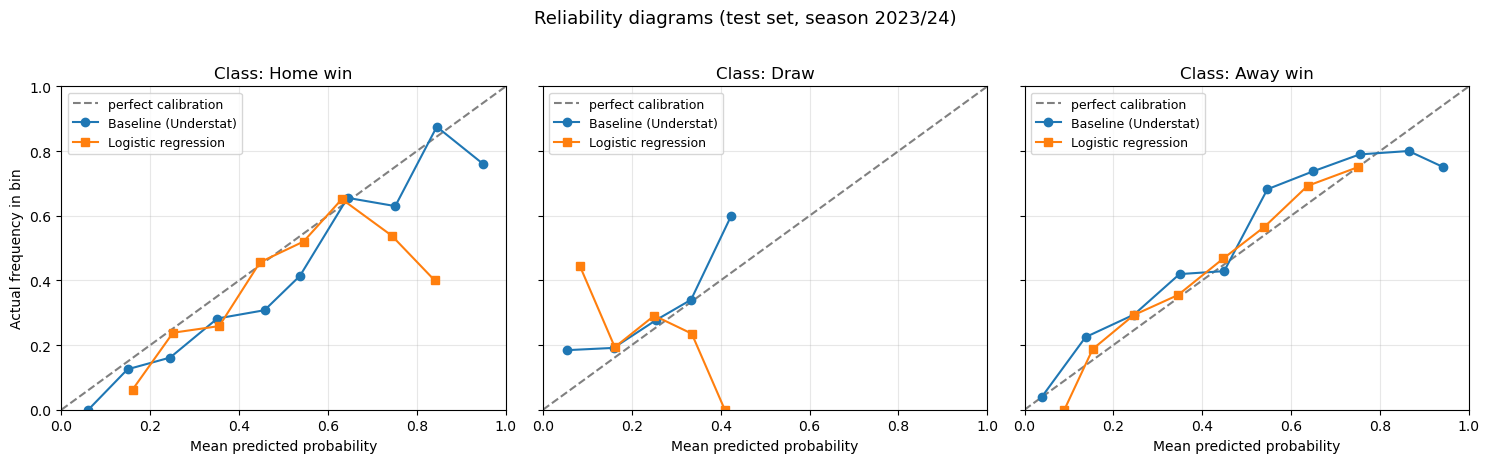

In [63]:
# 5.5 — Reliability diagram (per class).
# For each class c, bin the test set by predicted probability of c, then plot the
# AVERAGE predicted probability vs the ACTUAL frequency of class c in that bin.
# A perfectly calibrated model lies on the diagonal y = x.

def reliability_curve(y_true, proba, class_idx, n_bins=10):
    p = proba[:, class_idx]
    y_binary = (y_true == class_idx).astype(int)
    bins = np.linspace(0, 1, n_bins + 1)
    bin_ids = np.digitize(p, bins) - 1
    bin_ids = np.clip(bin_ids, 0, n_bins - 1)
    mean_pred = np.array([p[bin_ids == b].mean() if (bin_ids == b).any() else np.nan
                          for b in range(n_bins)])
    frac_act  = np.array([y_binary[bin_ids == b].mean() if (bin_ids == b).any() else np.nan
                          for b in range(n_bins)])
    return mean_pred, frac_act

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5), sharey=True)
for i, (cls_idx, cls_name) in enumerate(zip([0, 1, 2], ['Home win', 'Draw', 'Away win'])):
    ax = axes[i]
    ax.plot([0, 1], [0, 1], color='gray', linestyle='--', label='perfect calibration')
    mp_b, fa_b = reliability_curve(y_test, baseline_proba_test, cls_idx)
    ax.plot(mp_b, fa_b, marker='o', label='Baseline (Understat)')
    mp_l, fa_l = reliability_curve(y_test, logreg_proba_test, cls_idx)
    ax.plot(mp_l, fa_l, marker='s', label='Logistic regression')
    ax.set_title(f'Class: {cls_name}')
    ax.set_xlabel('Mean predicted probability')
    if i == 0:
        ax.set_ylabel('Actual frequency in bin')
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.grid(alpha=0.3)
    ax.legend(fontsize=9)

plt.suptitle('Reliability diagrams (test set, season 2023/24)', y=1.02, fontsize=13)
plt.tight_layout()
plt.show()

## Step 6 — Feature regimes: team-level vs +FBref vs +player

Central question: *does adding FBref team statistics and player-level features improve predictive performance over a model with only basic team-level features?*

Three feature regimes:
- **A — team-level only.** Rolling xG / goals / form + Transfermarkt squad values. 29 features.
- **B — team + FBref.** Adds possession, attacker counts, FBref goal stats. ~50 features.
- **C — team + FBref + player.** Adds per-player GA90, squad depth, starter minutes. ~76 features.

**Common subset.** The B and C CSVs have many NaN (FBref scraping didn't cover seasons 2018 and 2021, and ~50 % of remaining matches). To compare the regimes fairly, we restrict the dataset to matches that have complete data in all 3 CSVs. Same matches, same baseline, same split across regimes — only the features change.

This drops the working set from 2086 to 585 matches (417 train + 168 test). Results in this section are not directly comparable to step 5 (different train and test set).

In [66]:
# 6.1 — Find the common subset of match_ids that are NaN-free in all 3 CSVs.

csv_paths = {
    'A_team' : '../data/ligue1_features.csv',
    'B_fbref': '../data/ligue1_fbref_features.csv',
    'C_player': '../data/ligue1_player_features.csv',
}

regime_dfs = {}
common_ids = None
for key, path in csv_paths.items():
    d = pd.read_csv(path, parse_dates=['date'])
    valid_ids = set(d.dropna()['match_id'])
    regime_dfs[key] = d
    print(f'{key:10s}: {d.shape[1]:3d} columns, {len(valid_ids):4d} NaN-free matches')
    common_ids = valid_ids if common_ids is None else common_ids & valid_ids

print(f'\nCommon subset (NaN-free in all 3 CSVs): {len(common_ids)} matches')

A_team    :  40 columns, 2086 NaN-free matches
B_fbref   :  61 columns,  724 NaN-free matches
C_player  :  87 columns,  585 NaN-free matches

Common subset (NaN-free in all 3 CSVs): 585 matches


C_player  :  87 columns,  585 NaN-free matches

Common subset (NaN-free in all 3 CSVs): 585 matches


In [68]:
# 6.2 — Define a reusable function that runs the full pipeline
# (split -> scale -> train -> evaluate) on a given CSV restricted to common_ids.
# Returns a dict of metrics so we can collect results across all 3 regimes.

def train_and_evaluate_regime(df_full, common_ids, regime_name):
    """Train logistic regression on a regime's features and return metrics.
    
    df_full     : the full DataFrame for this regime (from CSV).
    common_ids  : set of match_ids to restrict to (for apples-to-apples comparison).
    regime_name : string label for the report.
    """
    # Restrict to common subset, drop residual NaN (none expected), sort by date
    d = df_full[df_full['match_id'].isin(common_ids)].dropna().sort_values('date').reset_index(drop=True)
    
    # Identify feature columns: everything except IDs, target, and Understat (baseline)
    EXCLUDE = {'match_id', 'date', 'season', 'match_week', 'home_team', 'away_team',
               'result', 'result_code', 'home_win_prob', 'draw_prob', 'away_win_prob'}
    features = [c for c in d.columns if c not in EXCLUDE]
    
    # Temporal split
    train_mask = d['season'] < TEST_SEASON
    test_mask  = d['season'] == TEST_SEASON
    d_train = d[train_mask].reset_index(drop=True)
    d_test  = d[test_mask].reset_index(drop=True)
    
    X_tr = d_train[features].values; y_tr = d_train['result_code'].values
    X_te = d_test [features].values; y_te = d_test ['result_code'].values
    base = d_test [['home_win_prob', 'draw_prob', 'away_win_prob']].values
    
    # Scale + train
    sc = StandardScaler()
    X_tr_s = sc.fit_transform(X_tr)
    X_te_s = sc.transform(X_te)
    
    lr = LogisticRegression(multi_class='multinomial', solver='lbfgs',
                            C=1.0, max_iter=1000, random_state=RANDOM_STATE)
    lr.fit(X_tr_s, y_tr)
    proba = lr.predict_proba(X_te_s)
    
    return {
        'regime'        : regime_name,
        'n_features'    : len(features),
        'n_train'       : len(y_tr),
        'n_test'        : len(y_te),
        # Model metrics
        'logloss_model' : log_loss(y_te, proba, labels=[0, 1, 2]),
        'brier_model'   : brier_multiclass(y_te, proba),
        'acc_model'     : accuracy_score(y_te, proba.argmax(axis=1)),
        # Baseline metrics on the SAME test set (so they should be identical across regimes)
        'logloss_base'  : log_loss(y_te, base, labels=[0, 1, 2]),
        'brier_base'    : brier_multiclass(y_te, base),
        'acc_base'      : accuracy_score(y_te, base.argmax(axis=1)),
    }

print('train_and_evaluate_regime function defined.')

train_and_evaluate_regime function defined.


In [70]:
# 6.3 — Run the function on each of the 3 regimes.

results_list = []
for key, name in [('A_team', 'A: team-level'), ('B_fbref', 'B: +FBref'), ('C_player', 'C: +player')]:
    r = train_and_evaluate_regime(regime_dfs[key], common_ids, name)
    results_list.append(r)
    print(f'{name:18s} | features={r["n_features"]:3d} | train={r["n_train"]:3d} | test={r["n_test"]:3d}'
          f' | logreg log-loss={r["logloss_model"]:.4f}')

A: team-level      | features= 29 | train=417 | test=168 | logreg log-loss=1.0563
B: +FBref          | features= 50 | train=417 | test=168 | logreg log-loss=1.1351
C: +player         | features= 76 | train=417 | test=168 | logreg log-loss=1.2158


In [72]:
# 6.4 — Build the comparison table.
# Side by side: each regime's logreg vs the SAME baseline (computed once on the common test set).

results_df = pd.DataFrame(results_list).set_index('regime')

# Sanity check: the baseline metrics should be identical across regimes (same test set)
assert results_df['logloss_base'].nunique() == 1, 'Baseline log-loss differs between regimes!'
assert results_df['brier_base'].nunique()   == 1, 'Baseline Brier differs between regimes!'

# Display a clean side-by-side
summary = pd.DataFrame({
    'n_features'         : results_df['n_features'],
    'Log-loss (logreg)'  : results_df['logloss_model'].round(4),
    'Log-loss (baseline)': results_df['logloss_base'].round(4),
    'Log-loss delta'     : (results_df['logloss_model'] - results_df['logloss_base']).round(4),
    'Brier (logreg)'     : results_df['brier_model'].round(4),
    'Accuracy (logreg)'  : (results_df['acc_model'] * 100).round(1),
    'Accuracy (baseline)': (results_df['acc_base']  * 100).round(1),
})
print(f'Test set: {results_df["n_test"].iloc[0]} matches (season 2023/24, common subset).')
print()
print(summary)

Test set: 168 matches (season 2023/24, common subset).

               n_features  Log-loss (logreg)  Log-loss (baseline)  Log-loss delta  Brier (logreg)  Accuracy (logreg)  Accuracy (baseline)
regime                                                                                                                                   
A: team-level          29             1.0563               0.9104          0.1458          0.6325               49.4                 56.0
B: +FBref              50             1.1351               0.9104          0.2247          0.6675               44.6                 56.0
C: +player             76             1.2158               0.9104          0.3054          0.7028               45.8                 56.0


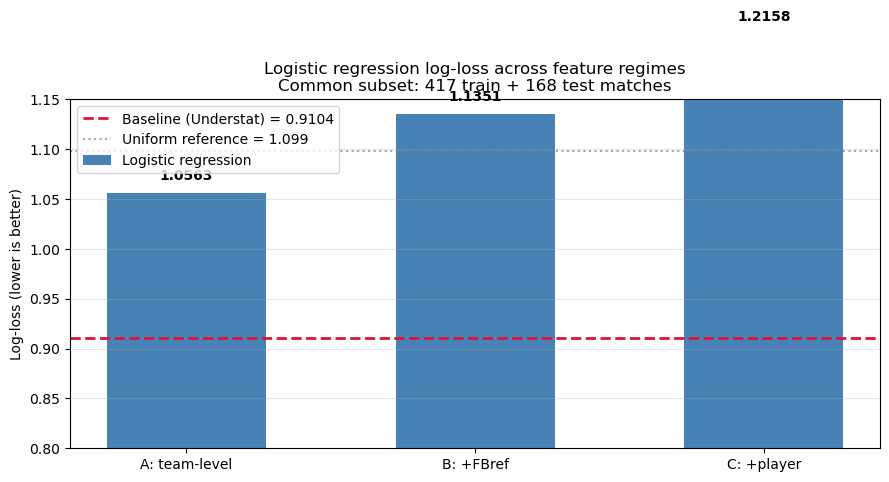

In [74]:
# 6.5 — Visualisation: log-loss across regimes vs baseline.
# This is THE figure for the presentation.

fig, ax = plt.subplots(figsize=(9, 5))

regimes = list(results_df.index)
x_pos = np.arange(len(regimes))
logreg_vals = results_df['logloss_model'].values
baseline_val = results_df['logloss_base'].iloc[0]

bars = ax.bar(x_pos, logreg_vals, width=0.55, color='steelblue', label='Logistic regression')
ax.axhline(baseline_val, color='crimson', linestyle='--', linewidth=2,
           label=f'Baseline (Understat) = {baseline_val:.4f}')
ax.axhline(-np.log(1/3), color='gray', linestyle=':', alpha=0.7,
           label='Uniform reference = 1.099')

# Annotate each bar with its value
for bar, v in zip(bars, logreg_vals):
    ax.text(bar.get_x() + bar.get_width()/2, v + 0.01, f'{v:.4f}',
            ha='center', va='bottom', fontsize=10, fontweight='bold')

ax.set_xticks(x_pos)
ax.set_xticklabels(regimes)
ax.set_ylabel('Log-loss (lower is better)')
ax.set_title('Logistic regression log-loss across feature regimes\n'
             f'Common subset: {results_df["n_train"].iloc[0]} train + {results_df["n_test"].iloc[0]} test matches')
ax.set_ylim(0.80, 1.15)
ax.grid(axis='y', alpha=0.3)
ax.legend(loc='upper left')
plt.tight_layout()
plt.show()

## Conclusions

Adding more features hurts: log-loss goes up monotonically from regime A (1.06) to B (1.14) to C (1.22). The Understat baseline at 0.91 stays out of reach in every regime.

The most plausible explanation is the curse of dimensionality combined with multicollinearity:

- 417 training matches against up to 76 features — the samples-to-features ratio is too low.
- Player-level statistics are highly correlated with the team-level aggregates (the correlation heatmap in the EDA already flagged this).
- Without strong regularisation (`C=1.0` is the default L2), logistic regression overfits the noise instead of extracting genuine signal.

Directions to extend this work:

- Stronger regularisation (L1, smaller `C`) for automatic feature selection.
- Tree-based models (Random Forest, XGBoost) that are less sensitive to multicollinearity — this is the next step in the team's pipeline.
- Bootstrap confidence intervals on the log-loss differences.
- Calibration of the logistic regression outputs (Platt scaling, isotonic regression).